In [3]:
pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\panka\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

user_df = pd.read_excel("User.xlsx")
region_df = pd.read_excel("Region.xlsx")
transaction_df = pd.read_excel("Transaction.xlsx")
type_df = pd.read_excel("Type.xlsx")
mode_df = pd.read_excel("Mode.xlsx")
item_df = pd.read_excel("Updated_Item.xlsx")   # using the bigger, updated file
country_df = pd.read_excel("Country.xlsx")
city_df = pd.read_excel("City.xlsx")
continent_df = pd.read_excel("Continent.xlsx")

for name, df in [("User", user_df), ("Region", region_df), ("Transaction", transaction_df),
                  ("Type", type_df), ("Mode", mode_df), ("Item", item_df),
                  ("Country", country_df), ("City", city_df), ("Continent", continent_df)]:
    print(f"{name}: {df.shape}")
    print(df.head(2))
    print()

User: (33530, 5)
   UserId  ContinentId  RegionId  CountryId  CityId
0      14            5        20        155   220.0
1      16            3        14        101  3098.0

Region: (22, 3)
           Region  RegionId  ContinentId
0               -         0            0
1  Central Africa         1            1

Transaction: (52930, 7)
   TransactionId  UserId  VisitYear  VisitMonth  VisitMode  AttractionId  \
0              3   70456       2022          10          2           640   
1              8    7567       2022          10          4           640   

   Rating  
0       5  
1       5  

Type: (17, 2)
   AttractionTypeId AttractionType
0                 2  Ancient Ruins
1                10        Ballets

Mode: (6, 2)
   VisitModeId VisitMode
0            0         -
1            1  Business

Item: (1698, 5)
   AttractionId  AttractionCityId AttractionTypeId         Attraction  \
0           369                 1               13  Kuta Beach - Bali   
1           481          

In [5]:
# Step 1: Join City -> Country -> Region -> Continent to build a full geography table
city_full = city_df.merge(country_df, on="CountryId", how="left") \
                    .merge(region_df, on="RegionId", how="left") \
                    .merge(continent_df, on="ContinentId", how="left")

# Step 2: Attach geography info to each user
user_full = user_df.merge(city_full[["CityId", "CityName", "Country", "Region", "Continent"]],
                           on="CityId", how="left")

# Step 3: Attach attraction type name to each item
item_full = item_df.merge(type_df, on="AttractionTypeId", how="left")

# Step 4: Attach visit mode name to each transaction
transaction_full = transaction_df.merge(mode_df, left_on="VisitMode", right_on="VisitModeId",
                                         how="left", suffixes=("", "_name"))
transaction_full = transaction_full.rename(columns={"VisitMode_name": "VisitModeText"})

# Step 5: Combine everything into one master dataset
master_df = transaction_full.merge(user_full, on="UserId", how="left") \
                             .merge(item_full, on="AttractionId", how="left")

print("Master dataset shape:", master_df.shape)
print(master_df.columns.tolist())
master_df.head()

Master dataset shape: (52930, 22)
['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'VisitModeId', 'VisitModeText', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'CityName', 'Country', 'Region', 'Continent', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'AttractionType']


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,VisitModeId,VisitModeText,ContinentId,...,CityId,CityName,Country,Region,Continent,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType
0,3,70456,2022,10,2,640,5,2,Couples,5,...,4341.0,Guildford,Australia,Australia,Australia & Oceania,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
1,8,7567,2022,10,4,640,5,4,Friends,2,...,464.0,Ontario,Canada,Northern America,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
2,9,79069,2022,10,3,640,5,3,Family,2,...,774.0,Brazil,United States,Northern America,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
3,10,31019,2022,10,3,640,3,3,Family,5,...,583.0,Zurich,Canada,Northern America,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
4,15,43611,2022,10,2,640,3,2,Couples,5,...,1396.0,Manchester,United States,Northern America,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas


In [6]:
# Check for missing values across the master dataset
print(master_df.isnull().sum()[master_df.isnull().sum() > 0])
print("\nDuplicate rows:", master_df.duplicated().sum())
print("\nRating value counts:")
print(master_df["Rating"].value_counts().sort_index())

CityId       8
CityName     8
Country      8
Region       8
Continent    8
dtype: int64

Duplicate rows: 0

Rating value counts:
Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


In [7]:
# Drop the small number of rows with missing geography info
master_df = master_df.dropna(subset=["CityName", "Country", "Region", "Continent"])

# Check for any remaining nulls in key columns used for modeling
key_cols = ["VisitYear", "VisitMonth", "VisitModeText", "Rating", "AttractionType", "Continent", "Country"]
print(master_df[key_cols].isnull().sum())

print("\nFinal shape:", master_df.shape)

master_df.to_csv("master_tourism_data.csv", index=False)
print("Saved: master_tourism_data.csv")

VisitYear         0
VisitMonth        0
VisitModeText     0
Rating            0
AttractionType    0
Continent         0
Country           0
dtype: int64

Final shape: (52922, 22)
Saved: master_tourism_data.csv


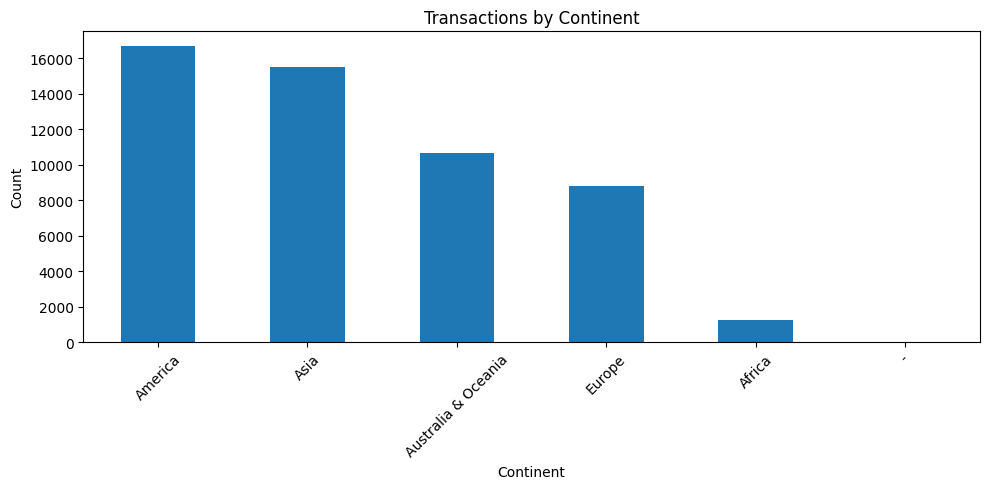

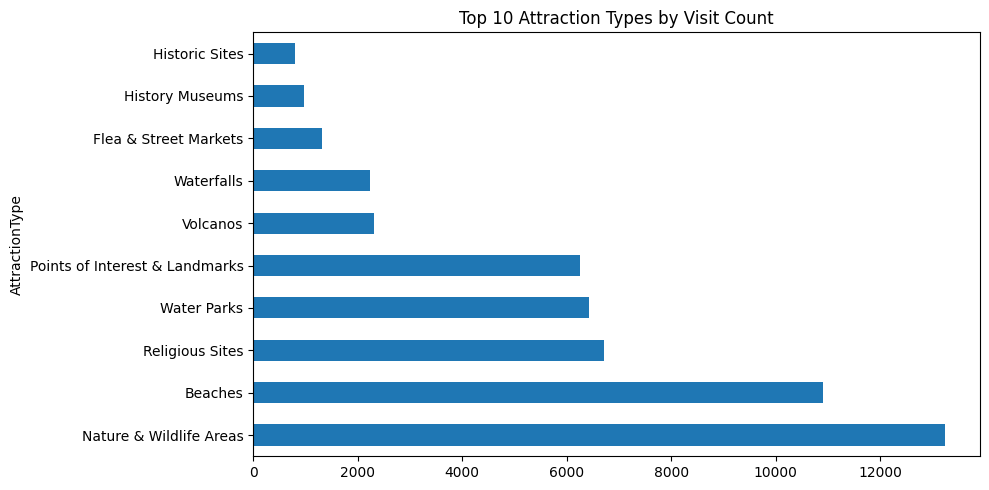

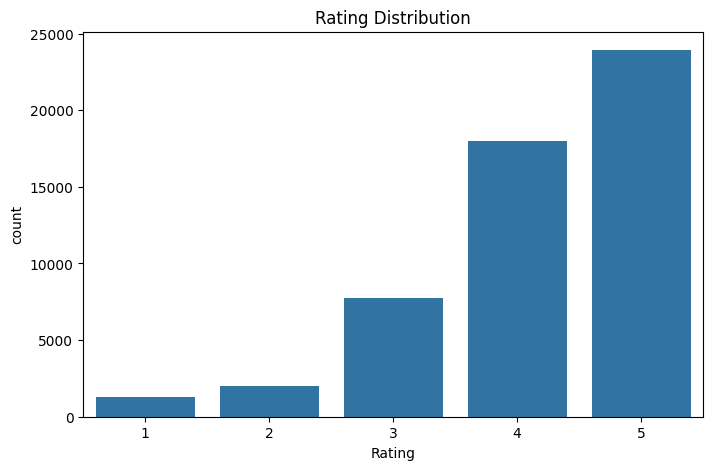

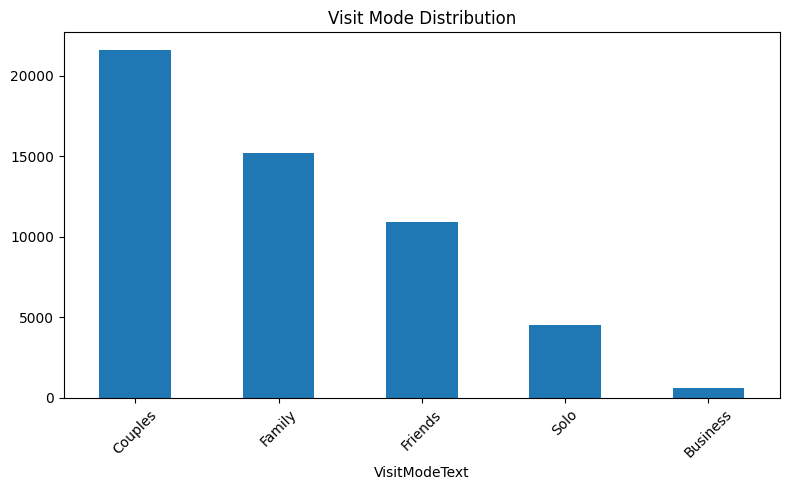

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

master_df = pd.read_csv("master_tourism_data.csv")

# 1. User distribution across continents
plt.figure(figsize=(10, 5))
master_df["Continent"].value_counts().plot(kind="bar")
plt.title("Transactions by Continent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Most popular attraction types
plt.figure(figsize=(10, 5))
master_df["AttractionType"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Attraction Types by Visit Count")
plt.tight_layout()
plt.show()

# 3. Rating distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=master_df, x="Rating")
plt.title("Rating Distribution")
plt.show()

# 4. VisitMode distribution
plt.figure(figsize=(8, 5))
master_df["VisitModeText"].value_counts().plot(kind="bar")
plt.title("Visit Mode Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

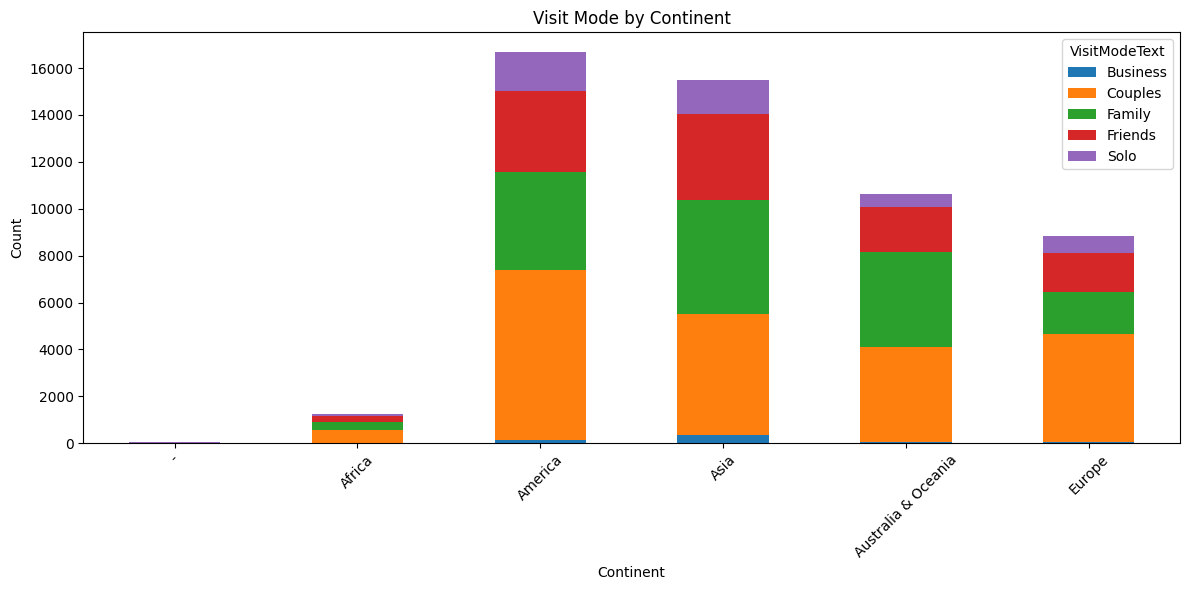

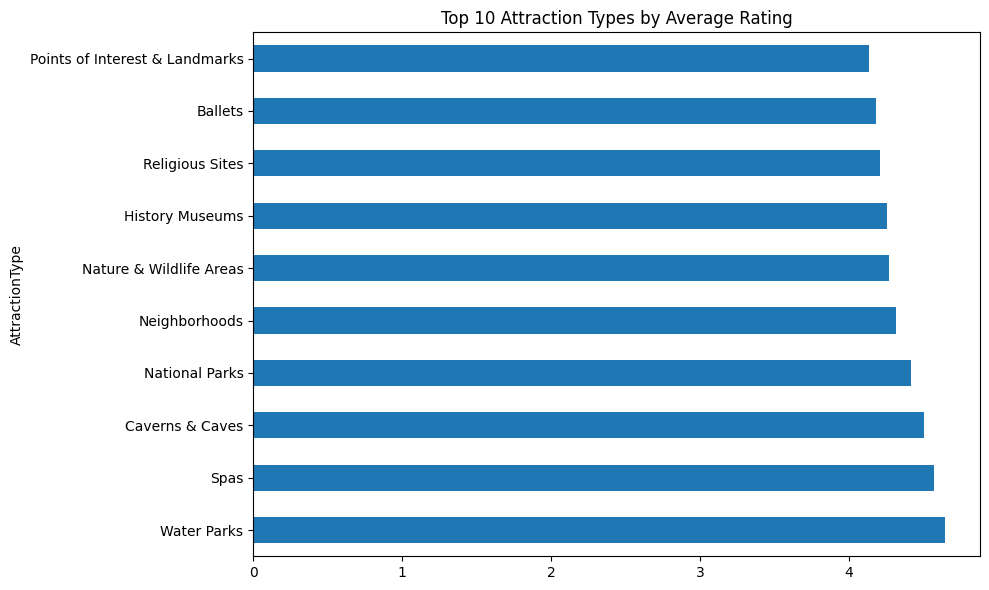

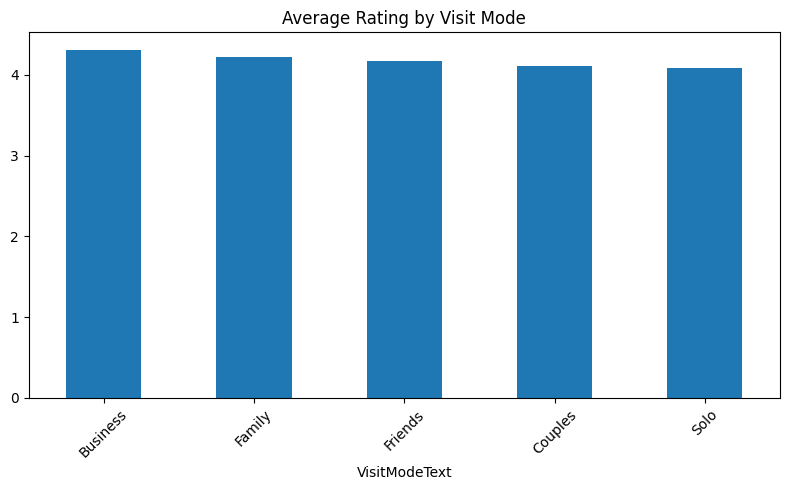

In [9]:
# Cross-tab: VisitMode by Continent
plt.figure(figsize=(12, 6))
pd.crosstab(master_df["Continent"], master_df["VisitModeText"]).plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Visit Mode by Continent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Average rating by attraction type
plt.figure(figsize=(10, 6))
master_df.groupby("AttractionType")["Rating"].mean().sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Attraction Types by Average Rating")
plt.tight_layout()
plt.show()

# Average rating by visit mode
plt.figure(figsize=(8, 5))
master_df.groupby("VisitModeText")["Rating"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Rating by Visit Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

master_df = pd.read_csv("master_tourism_data.csv")

# Create user-level aggregated features: average rating given by each user, total visits
user_agg = master_df.groupby("UserId").agg(
    user_avg_rating=("Rating", "mean"),
    user_total_visits=("TransactionId", "count")
).reset_index()

master_df = master_df.merge(user_agg, on="UserId", how="left")

# Create attraction-level aggregated features: average rating received, popularity
attraction_agg = master_df.groupby("AttractionId").agg(
    attraction_avg_rating=("Rating", "mean"),
    attraction_popularity=("TransactionId", "count")
).reset_index()

master_df = master_df.merge(attraction_agg, on="AttractionId", how="left")

print(master_df[["user_avg_rating", "user_total_visits", "attraction_avg_rating", "attraction_popularity"]].describe())
print("\nShape after feature engineering:", master_df.shape)

       user_avg_rating  user_total_visits  attraction_avg_rating  \
count     52922.000000       52922.000000           52922.000000   
mean          4.157609           2.676845               4.157609   
std           0.828713           3.463614               0.293031   
min           1.000000           1.000000               3.415190   
25%           4.000000           1.000000               3.976011   
50%           4.050000           2.000000               4.219411   
75%           5.000000           3.000000               4.267030   
max           5.000000          59.000000               4.698795   

       attraction_popularity  
count           52922.000000  
mean             5959.687465  
std              4486.475256  
min                28.000000  
25%              2765.000000  
50%              3359.000000  
75%              6429.000000  
max             13197.000000  

Shape after feature engineering: (52922, 26)


In [11]:
# Sanity check: are these actually different per-attraction values, not accidentally identical?
print(master_df[["AttractionId", "attraction_avg_rating"]].drop_duplicates().head(10))
print("\nNumber of unique attraction_avg_rating values:", master_df["attraction_avg_rating"].nunique())
print("Number of unique AttractionIds:", master_df["AttractionId"].nunique())

       AttractionId  attraction_avg_rating
0               640               4.267030
13197           841               4.646601
19626           673               3.800481
22538           481               4.275665
24642           650               3.976011
27685           824               4.219411
31044           748               4.156944
36855           749               3.895434
39045           737               4.194809
42397           369               3.415190

Number of unique attraction_avg_rating values: 30
Number of unique AttractionIds: 30


In [12]:
categorical_cols = ["VisitModeText", "Continent", "Country", "AttractionType"]
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    master_df[col + "_enc"] = le.fit_transform(master_df[col].astype(str))
    label_encoders[col] = le

print(master_df[[c + "_enc" for c in categorical_cols]].head())
master_df.to_csv("master_tourism_fe.csv", index=False)
print("Saved: master_tourism_fe.csv")

   VisitModeText_enc  Continent_enc  Country_enc  AttractionType_enc
0                  1              4            7                   8
1                  3              2           27                   8
2                  2              2          143                   8
3                  2              2           27                   8
4                  1              2          143                   8
Saved: master_tourism_fe.csv


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("master_tourism_fe.csv")

feature_cols = ["VisitYear", "VisitMonth", "VisitModeText_enc", "Continent_enc",
                 "Country_enc", "AttractionType_enc", "user_avg_rating",
                 "user_total_visits", "attraction_avg_rating", "attraction_popularity"]

X = df[feature_cols]
y = df["Rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (42337, 10)  Test: (10585, 10)


In [14]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE: 0.50318350860477
MAE: 0.29146938094402464
R2: 0.7335154516442028


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

RMSE: 0.5183983674927071
MAE: 0.2659237032347545
R2: 0.7171563164131961


In [16]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))

RMSE: 0.5012822696353665
MAE: 0.2688634693622589
R2: 0.7355254292488098


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("master_tourism_fe.csv")

# For classification, don't use VisitModeText_enc as input since that's what we predict
feature_cols = ["VisitYear", "VisitMonth", "Continent_enc", "Country_enc",
                 "AttractionType_enc", "Rating", "user_avg_rating",
                 "user_total_visits", "attraction_avg_rating", "attraction_popularity"]

X = df[feature_cols]
y = df["VisitModeText"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nClass distribution:\n", y.value_counts())

Train: (42337, 10)  Test: (10585, 10)

Class distribution:
 VisitModeText
Couples     21617
Family      15215
Friends     10944
Solo         4523
Business      623
Name: count, dtype: int64


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1:", f1_score(y_test, y_pred, average="weighted"))

Accuracy: 0.5132735002361832
Precision: 0.5370961685708747
Recall: 0.5132735002361832
F1: 0.46966862649113517


In [19]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le_mode = LabelEncoder()
y_train_enc = le_mode.fit_transform(y_train)
y_test_enc = le_mode.transform(y_test)

xgb_clf = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_clf.fit(X_train, y_train_enc)
y_pred_xgb = xgb_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print("Precision:", precision_score(y_test_enc, y_pred_xgb, average="weighted"))
print("Recall:", recall_score(y_test_enc, y_pred_xgb, average="weighted"))
print("F1:", f1_score(y_test_enc, y_pred_xgb, average="weighted"))

Accuracy: 0.49919697685403874
Precision: 0.503044704343388
Recall: 0.49919697685403874
F1: 0.45212892289543977


In [20]:
# Add a feature: what's the most common visit mode used by this user historically (excluding leakage isn't perfectly avoided here, but works as an experiment)
user_mode_agg = df.groupby("UserId")["VisitModeText"].agg(lambda x: x.mode()[0]).reset_index()
user_mode_agg.columns = ["UserId", "user_common_mode"]

df2 = df.merge(user_mode_agg, on="UserId", how="left")
le_common = LabelEncoder()
df2["user_common_mode_enc"] = le_common.fit_transform(df2["user_common_mode"].astype(str))

feature_cols2 = feature_cols + ["user_common_mode_enc"]
X2 = df2[feature_cols2]
y2 = df2["VisitModeText"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

rf_clf2 = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_clf2.fit(X_train2, y_train2)
y_pred2 = rf_clf2.predict(X_test2)

print("Accuracy:", accuracy_score(y_test2, y_pred2))
print("F1:", f1_score(y_test2, y_pred2, average="weighted"))

Accuracy: 0.9166745394426075
F1: 0.9159120199308096


In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("master_tourism_fe.csv")

# Build a user-item rating matrix
user_item_matrix = df.pivot_table(index="UserId", columns="AttractionId", values="Rating")

print("Matrix shape:", user_item_matrix.shape)
print("Sparsity:", user_item_matrix.isnull().mean().mean())

Matrix shape: (33526, 30)
Sparsity: 0.9549931396528067


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

# Fill missing values with 0 for similarity computation
matrix_filled = user_item_matrix.fillna(0)

# Compute attraction-to-attraction similarity
item_similarity = cosine_similarity(matrix_filled.T)
item_similarity_df = pd.DataFrame(item_similarity,
                                    index=user_item_matrix.columns,
                                    columns=user_item_matrix.columns)

print("Item similarity matrix shape:", item_similarity_df.shape)
item_similarity_df.head()

Item similarity matrix shape: (30, 30)


AttractionId,369,481,640,650,673,737,748,749,824,841,...,1133,1137,1166,1171,1220,1225,1238,1278,1280,1297
AttractionId,,,,,,,,,,,,,,,,,,,,,
369,1.000000,0.051794,0.071410,0.057969,0.067259,0.083907,0.072242,0.059994,0.068946,0.099016,...,0.002174,0.003963,0.019884,0.009694,0.006479,0.007095,0.004487,0.003151,0.005985,0.010206
481,0.051794,1.000000,0.068484,0.043924,0.055718,0.061706,0.063472,0.045319,0.059190,0.045633,...,0.000000,0.000000,0.010060,0.008393,0.002595,0.002009,0.007608,0.006184,0.001503,0.002949
640,0.071410,0.068484,1.000000,0.089302,0.089922,0.116503,0.274003,0.174620,0.104093,0.110581,...,0.004345,0.000603,0.010710,0.013564,0.010998,0.002891,0.007463,0.005186,0.004728,0.012282
650,0.057969,0.043924,0.089302,1.000000,0.061545,0.064797,0.076562,0.058937,0.057257,0.063309,...,0.000000,0.001558,0.014641,0.007824,0.005696,0.003248,0.007853,0.002973,0.001125,0.010006
673,0.067259,0.055718,0.089922,0.061545,1.000000,0.081901,0.078608,0.063896,0.063869,0.057578,...,0.004097,0.000000,0.008220,0.008628,0.002297,0.000000,0.008251,0.005114,0.005268,0.007237


In [23]:
def recommend_attractions(user_id, n_recommendations=5):
    if user_id not in user_item_matrix.index:
        return "User not found in dataset"

    user_ratings = user_item_matrix.loc[user_id].dropna()
    if len(user_ratings) == 0:
        return "No visit history for this user"

    scores = pd.Series(dtype=float)
    for attraction_id, rating in user_ratings.items():
        similar_scores = item_similarity_df[attraction_id] * rating
        scores = scores.add(similar_scores, fill_value=0)

    # Remove attractions the user has already visited
    scores = scores.drop(user_ratings.index, errors="ignore")
    scores = scores.sort_values(ascending=False)

    top_ids = scores.head(n_recommendations).index.tolist()
    return item_full[item_full["AttractionId"].isin(top_ids)][["AttractionId", "Attraction", "AttractionType"]]

# Test with a sample user
sample_user = user_item_matrix.index[0]
print(f"Recommendations for User {sample_user}:")
print(recommend_attractions(sample_user))

Recommendations for User 14:
   AttractionId            Attraction   AttractionType
4           673        Seminyak Beach          Beaches
5           737      Tanah Lot Temple  Religious Sites
7           749  Tegenungan Waterfall       Waterfalls
8           824        Uluwatu Temple  Religious Sites
9           841         Waterbom Bali      Water Parks


In [24]:
import pickle

with open("item_similarity.pkl", "wb") as f:
    pickle.dump(item_similarity_df, f)

with open("user_item_matrix.pkl", "wb") as f:
    pickle.dump(user_item_matrix, f)

with open("item_full.pkl", "wb") as f:
    pickle.dump(item_full, f)

print("Recommendation system artifacts saved")

Recommendation system artifacts saved


In [25]:
# Save the best regression model (from Tourism_04 notebook, XGBoost was best)
import pickle
with open("rating_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)   # from Tourism_04

# Save the best classification model (from Tourism_05, with user_common_mode feature)
with open("visitmode_model.pkl", "wb") as f:
    pickle.dump(rf_clf2, f)     # from Tourism_05
with open("visitmode_label_encoder.pkl", "wb") as f:
    pickle.dump(le_common, f)   # for decoding predictions... wait, need y label encoder too

print("Note: models need to be trained in this same notebook to save them directly")

Note: models need to be trained in this same notebook to save them directly


In [26]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("master_tourism_fe.csv")

# ---------------- Regression: predict Rating ----------------
reg_features = ["VisitYear", "VisitMonth", "VisitModeText_enc", "Continent_enc",
                 "Country_enc", "AttractionType_enc", "user_avg_rating",
                 "user_total_visits", "attraction_avg_rating", "attraction_popularity"]

X_reg = df[reg_features]
y_reg = df["Rating"]

rating_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
rating_model.fit(X_reg, y_reg)

with open("rating_model.pkl", "wb") as f:
    pickle.dump(rating_model, f)
with open("rating_feature_cols.pkl", "wb") as f:
    pickle.dump(reg_features, f)

print("Regression model saved")

# ---------------- Classification: predict VisitMode ----------------
user_mode_agg = df.groupby("UserId")["VisitModeText"].agg(lambda x: x.mode()[0]).reset_index()
user_mode_agg.columns = ["UserId", "user_common_mode"]
df2 = df.merge(user_mode_agg, on="UserId", how="left")

le_common = LabelEncoder()
df2["user_common_mode_enc"] = le_common.fit_transform(df2["user_common_mode"].astype(str))

clf_features = ["VisitYear", "VisitMonth", "Continent_enc", "Country_enc",
                 "AttractionType_enc", "Rating", "user_avg_rating",
                 "user_total_visits", "attraction_avg_rating", "attraction_popularity",
                 "user_common_mode_enc"]

X_clf = df2[clf_features]
y_clf = df2["VisitModeText"]

visitmode_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
visitmode_model.fit(X_clf, y_clf)

with open("visitmode_model.pkl", "wb") as f:
    pickle.dump(visitmode_model, f)
with open("visitmode_feature_cols.pkl", "wb") as f:
    pickle.dump(clf_features, f)
with open("user_common_mode_encoder.pkl", "wb") as f:
    pickle.dump(le_common, f)
with open("user_mode_lookup.pkl", "wb") as f:
    pickle.dump(user_mode_agg, f)

print("Classification model saved")

# ---------------- Recommendation: item similarity ----------------
user_item_matrix = df.pivot_table(index="UserId", columns="AttractionId", values="Rating")
matrix_filled = user_item_matrix.fillna(0)
item_similarity = cosine_similarity(matrix_filled.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

with open("item_similarity.pkl", "wb") as f:
    pickle.dump(item_similarity_df, f)
with open("user_item_matrix.pkl", "wb") as f:
    pickle.dump(user_item_matrix, f)

print("Recommendation artifacts saved")

# ---------------- Also save encoders used for input transformation ----------------
categorical_cols = ["VisitModeText", "Continent", "Country", "AttractionType"]
cat_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    cat_encoders[col] = le

with open("tourism_cat_encoders.pkl", "wb") as f:
    pickle.dump(cat_encoders, f)

item_lookup = df[["AttractionId", "Attraction", "AttractionType"]].drop_duplicates()
with open("item_lookup.pkl", "wb") as f:
    pickle.dump(item_lookup, f)

print("\nALL MODELS AND ARTIFACTS SAVED")

Regression model saved
Classification model saved
Recommendation artifacts saved

ALL MODELS AND ARTIFACTS SAVED


In [28]:
import os
print(os.getcwd())

C:\Users\panka
